In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Online Notebook:** https://learnpytorch.io

# ✨ Outline of Today's Notebook: 

1. PyTorch Workflow and Getting Set Up
2. Getting the data and loading it
3. Splitting the data to train and test sets
4. Building a function to visulize our data
5. Making our first model
6. Gradient Decent
7. Different PyTorch Classes for workflow
8. Training a model and Loss function


YT covered till: `5:49:09`

## 🔵 PyTorch Workflow:

We will explore an example of pytorch end-to-end workflow. 

In [3]:
what_we_covering = {1: "data (prepare and load)", 
                      2: "build model", 
                      3: "training/fit the model to data", 
                      4: "making predications and evaluationg (inference)", 
                      5: "how to save and load the model", 
                      6: "putting it all together"}
what_we_covering 

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'training/fit the model to data',
 4: 'making predications and evaluationg (inference)',
 5: 'how to save and load the model',
 6: 'putting it all together'}

In [4]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version: (should be more than 1.8)
torch.__version__

'2.8.0'

## 🔵 1. Data (Preparing and Data)

Data can be almost anything in ML. Examples:

* Excel spreadsheets
* Images of any kind
* Videos
* Audio like songs and podcasts
* DNA
* Text
  
Machine learning is a game of tow parts:
1. Get the data into a numerical representation
2. Building a model to make patterns in the numerical representations

To showcase this, let's create some *known* data using the linear regression formula.

We'll use linear regression formula to make straight line with known **parameter**. The formula: `Y=aX + b`

In [5]:
# Create known parameters

weight = 0.7 # b = slope
bias = 0.3 # a = constant

# Create 
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
# Unsqueeze adds another [] and makes the data easier to visualize

y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [6]:
len(X), len(y)

(50, 50)

Right now what we have done is that we got some tensor values as **input** which is X. And also we got y as our vector of **output**. We know that the **pattern** between them is a linear regression since we have used `y = aX + b` formula. 

The goal in ML is that we have the input and also the output, and we have to find what pattern is happening between them. 

### 🟢 Splitting the data to train and test sets: 

**Very important step in machine learning**

We've got some data.

But before we build a model we need to split it up.

One of most important steps in a machine learning project is creating a training and test set (and when required, a validation set).

| Split | Purpose | Amount of total data | How often is it used? |
| ----- | ----- | ----- | ----- |
| **Training set** | The model learns from this data (like the course materials you study during the semester). | ~60-80% | Always |
| **Validation set** | The model gets tuned on this data (like the practice exam you take before the final exam). | ~10-20% | Often but not always |
| **Testing set** | The model gets evaluated on this data to test what it has learned (like the final exam you take at the end of the semester). | ~10-20% | Always |

For now, we'll just use a training and test set, this means we'll have a dataset for our model to learn on as well as be evaluated on.

We can create them by splitting our `X` and `y` tensors.

> **Note:** When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn from training data and then evaluate it on test data to get an indication of how well it **generalizes** to unseen examples.


In [7]:
# Create a train/test split:
train_split = int(0.8 * len(X)) # Since 80% is train

X_train, y_train_target = X[:train_split], y[:train_split]
X_test, y_test_target = X[train_split:], y[train_split:]

len(X_train), len(y_train_target), len(X_test), len(y_test_target)

(40, 40, 10, 10)

### 🟢 Visulizing our Data:

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [8]:
def plot_perdictions(train_data=X_train, 
                     train_labels=y_train_target, 
                     test_data=X_test, 
                     test_labels=y_test_target, 
                     perdictions=None):
    '''
        Plots training data, test data and compare perdictions. 
    '''
    plt.figure(figsize=(10, 7))

    # Plot training data in blue:
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot training data in blue:
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")


    # Are there perdictions?
    if perdictions is not None:
        # Plot the perdictions if they exist:

        plt.scatter(test_data, perdictions, c="r", s=4, label="Perdictions")

    # Show the legend:
    plt.legend(prop={"size":14})

    '''
    New Functions:
        1. Plotting the data as a graph:
            plt.scatter(input_data(x), output_data(y), color (c="b/r/g/y"), 
                        size (s=int), label="nameOfData")

        2. Plotting the data info (Training data, Testsing data, ...)
            plt.legend(prop={"size":int})
    '''

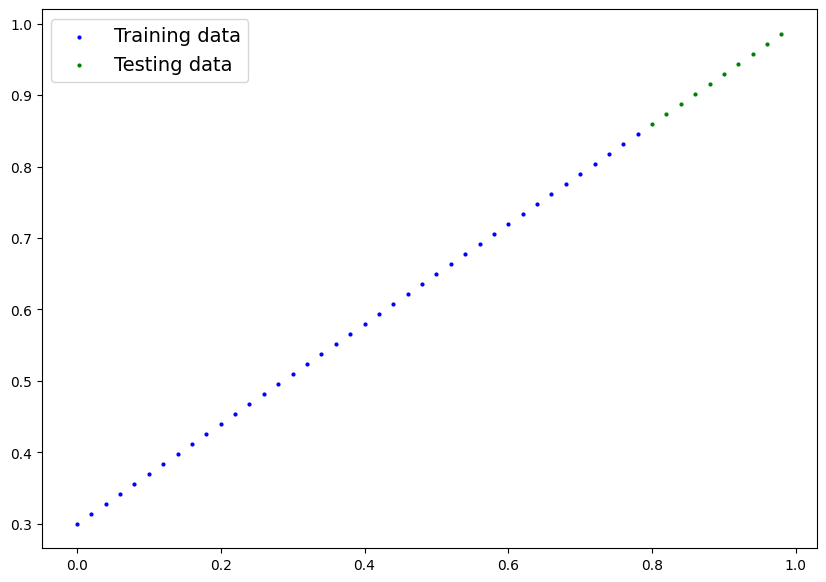

In [9]:
plot_perdictions()

## 🔵 2. Build the Model

Our first PyTorch Model!

We create a linear regression model. The formula: `Y = aX + B`

The whole goal of our model is to start with random numbers and parameters, look at the data (training data), and update those random numbers to represent the data. 

This way, we have a formula that represents the data we have, and it will work for any other unseen data. 

**What does our Model do?**
1. Start with random values (weight and bias)
2. Look at training data
3. Adjust the random values to get closer to ideal values (the weight and bias that created our data)

**How does it do so?** Two main algorithms:
1. Gradient descent
2. Backpropagation

In [10]:
# Create linear regression model class. 
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherhits from nn.Module
    '''
        For a class we need: 
        - its constants and global variables, 
        - attributes, 
        - constructor, 
        - modifiers and accessors, 
        - and computational methods. 

        What do we need? 
                1. subclass nn.Module --> contains all the building blocks 
                in neural networks. 

                2. Model parameters --> We make all the variables and paramters 
                we need for our model, like bias, weights, and more. 

                3. requires_grad = True means the pytorch will take care 
                of the gradients. 

                4. ANY SUBCLASS OF nn.Module NEEDS a forward() method!!
                Goal of forward: Defines the computation that model do. 
                Such as the linear regression formula ax + b
    '''
    
    # Constructor:
    def __init__(self):
        super().__init__()
        # nn.Paramer is a kind of tensor
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)


    # Forward method to define the computation in the model:
    def forward(self, x: torch.tensor) -> torch.Tensor: # <- x is the input data
        
        # this is the linear regression formula (y = m*x + b)
        return self.weights * x + self.bias


## 🔵 3. Model Building classes in PyTorch 

1. torch.nn - Contains all of the building blocks for computational graphs (a neural network can be considered a computationla graph)
2. torch.nn.Prameter - What prarmeters our model try and learn, often a PyTorch Layer from torch.nn will set these for us.
3. torch.nn.Module - The base class for all neura lnetwork moduels. If you subclass it, you should override forward().
4. torch.optim - this where the optimise in PyTorch Live, they will help with **gradient descent**
5. def forward() - All nn.Module subclasses require you to override forward(), this method define what happens in the computation of our model. 


**PyTorch Cheat Sheet:** https://docs.pytorch.org/tutorials/index.html

### 🟢 4. Review the steps: 

1. Getting the data ready:


   `torchvision.transforms`

   
   `torch.utils.data.Dataset`

   
   `torch.utils.data.DataLoader`

3. Building a pretrained model:


    `torch.nn`

   
    `torch.nn.Module`

   
    `torchvision.models`
   

4. Optimizing the model:

    `torch.optim`


And there are more as well that we will continue learning!

 ## 🔵 Contents of Linear Regression Model:

 Now we created a model, let's see what's inside. 

 So we can check out our model prarmeters or what's inside the model using `.parameters()` or `modelName.state_dict()`

In [11]:
# create a random seed: 
# We need to have these randomizations saved. 

torch.manual_seed(42)

# create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

list(model_0.parameters())

# Our model has started with random values and parameters; our ideal model will look at the training model
# and adjust those values to best represent the data. 

# But we also have the known parameters; our whole goal is to change these random parameters
# to the known values. 


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [12]:
# List named parameters: 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [13]:
weight, bias

(0.7, 0.3)

### 🟢 Making Perdictions of Model:

We use `torch.inference_model()`

Torch checks our model's predictive power, we see how well it predicts the `y_test` based on `x_test`. 

When we pass data through our model, it's going to run it through the `forward()` method. 

In [14]:
print("The ideal model will take the first set of tensors as X, and outputs those y values. ")
print(X_test)
print()
print(y_test_target)

The ideal model will take the first set of tensors as X, and outputs those y values. 
tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


In [15]:
# Make predictions with the model. 
y_preds = model_0(X_test)
print(y_preds)


# Better way to do it:
# This way the computation will be faster. 

with torch.inference_mode(): 
    y_preds_better = model_0(X_test)

print(y_preds_better)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


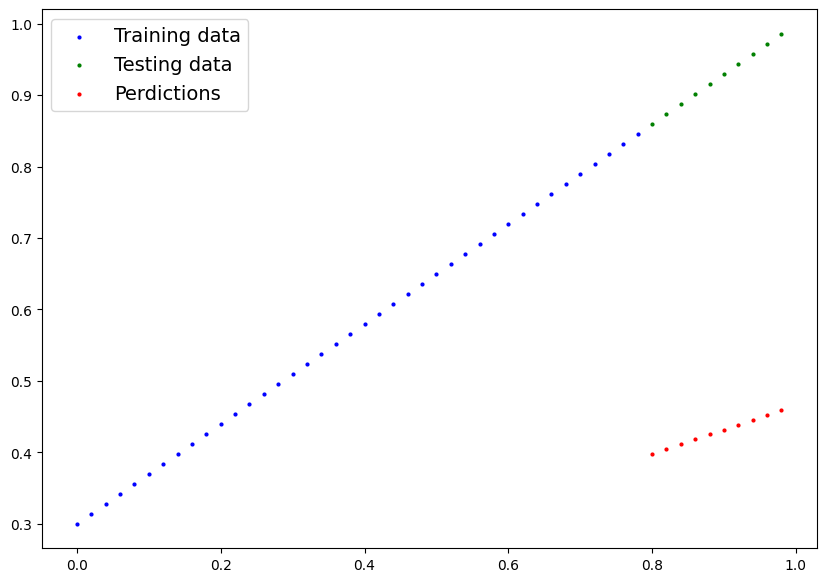

In [16]:
plot_perdictions(perdictions=y_preds_better)

## 🔵 4. Train Model

The whole idea of training a model is to move from some unknown parameters to some known parameters. 

Things we need to train: 

* **Loss Function** (Cost function): Measuring the poorness of models' predictions.
* They are a function to measure how wrong your model's predictions are compared to ideal outputs. So the lower, the better.
* **Optimizer**: Takes into account the loss of a model and adjusts the model's parameters (e.g. weights and biases) to improve the loss function.

In PyTorch, we need: 
* A training loop
* A testing loop

### 🟢 Loss functions: 

The goal is to minimize the value of loss function/. 

* **torch.nn.L1Loss:** The average mean of the absolute difference between the target and predicted value.


### 🟢 Optimizer functions: 
An optimizer will adjust the parameters to lower the loss function. 

* **torch.optim:** Take the loss function into account and optimize that. Ex: SGD (gradient descent algorithm), Adam, ...

Inputs: 
- parameters (model.parameters()), 
- learning rate = The most important hyperparameter you can set. It tells the optimizer how far its steps should be when changing the parameters. 

In [17]:
# Set up a loss function: 
loss_fn = nn.L1Loss()

# Set up an optimizer: (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                           lr=0.01)


**Important Question:** 

Which loss function and optimizer should I use? 

- It is problem-specific. Examples:
- Linear regression uses Loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()`
- Classification problem: Loss function of `nn.BCELoss`. 


### 🟢 Building a training and testing loop in PyTorch: 

* Training Loop:
0. Loop through the data and do...
1. Forward pass/propogation using `forward()` to make predictions on data.
3. Calculate the loss (compare forward pass predictions to ground truth labels)
4. Optimizer zero grad
5. Loss backward - Move backwards through the network to calculate the gradients of each of the parameters of our model wrt to the loss. (**backpropagation**)
6. Optimizer step - Use the optimizer to adjust our model's parameters to try to improve the loss. (**gradient descent**)

In [18]:
# An epoch is one loop through the  (this is a hyperparameter bc we set it ourselves)
epochs = 200

# Track different values: 
epoch_count = []
loss_values = []
test_loss_values = []

### Training:
# 0. Loop through the data
for epoch in range(epochs): 

    # set the model to training mode: 
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients. 
    
    
    # 1. forward pass:
    y_pred = model_0(X_train)

    # 2. Calc the loss: 
    train_loss = loss_fn(y_pred, y_train_target)
    # print(f"Loss: {loss}")

    # 3. optimizer zero grad
    optimizer.zero_grad()

    # 4. perform backpropagation wrt parameters of the model
    # This is basically calculating the gradient based on the loss of that 
    # step. 
    train_loss.backward()

    # 5. Set the optimizer (perform the gradient descent
    # By default, the optimizer changes will accumulate through the loop
    # We have to zero the above in step 3
    optimizer.step()
    # Now we update the gradient 

    ### Testing: 


    # step 0:
    model_0.eval() # turn off settings that are not needed in evaluation/testing
    with torch.inference_mode(): # this turns off gradient tracking which is required when getting y_preds/y_test
        y_test = model_0(X_test)

    # 1. calc the loss: 
    test_loss = loss_fn(y_test, y_test_target)

    if epoch % 10 == 0 and epoch!= 0: 
        epoch_count.append(epoch)
        loss_values.append(train_loss.detach())
        test_loss_values.append(test_loss.detach())

        
        print(f"Epoch:{epoch} | Loss: {train_loss} | Test Loss: {test_loss}")
        print(model_0.state_dict())
        print()

    ## Printing out the model's current bias and weight:
    


Epoch:10 | Loss: 0.1976713389158249 | Test Loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])

Epoch:20 | Loss: 0.08908725529909134 | Test Loss: 0.2172965705394745
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])

Epoch:30 | Loss: 0.053148530423641205 | Test Loss: 0.14464019238948822
OrderedDict([('weights', tensor([0.4512])), ('bias', tensor([0.3768]))])

Epoch:40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953748226166
OrderedDict([('weights', tensor([0.4748])), ('bias', tensor([0.3868]))])

Epoch:50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict([('weights', tensor([0.4938])), ('bias', tensor([0.3843]))])

Epoch:60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633813381195
OrderedDict([('weights', tensor([0.5116])), ('bias', tensor([0.3788]))])

Epoch:70 | Loss: 0.03476089984178543 | Test Loss: 0.0805937722325325
OrderedDict([('weights', tensor([0.5288])), ('bias', tensor([0.3718])

In [19]:
weight, bias

(0.7, 0.3)

In [20]:
loss_values, test_loss_values

([tensor(0.1977),
  tensor(0.0891),
  tensor(0.0531),
  tensor(0.0454),
  tensor(0.0417),
  tensor(0.0382),
  tensor(0.0348),
  tensor(0.0313),
  tensor(0.0279),
  tensor(0.0245),
  tensor(0.0210),
  tensor(0.0176),
  tensor(0.0142),
  tensor(0.0107),
  tensor(0.0073),
  tensor(0.0039),
  tensor(0.0089),
  tensor(0.0089),
  tensor(0.0089)],
 [tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050)])

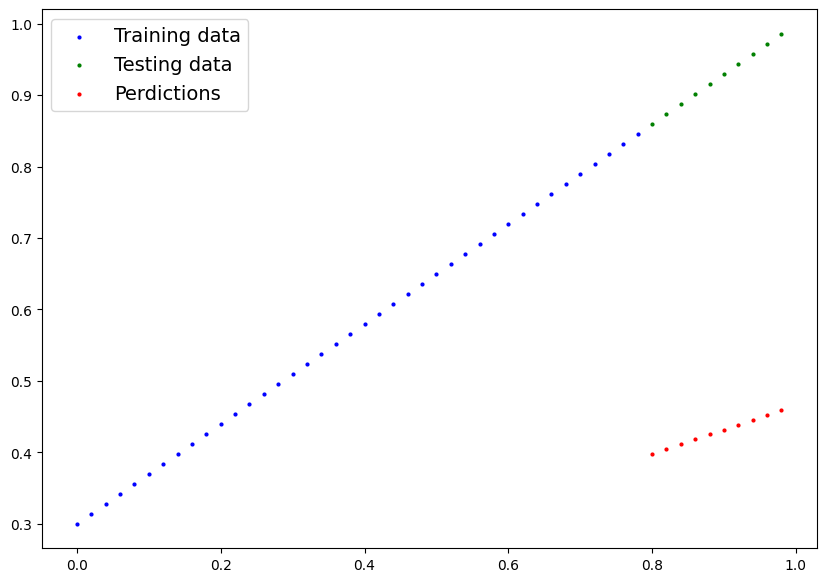

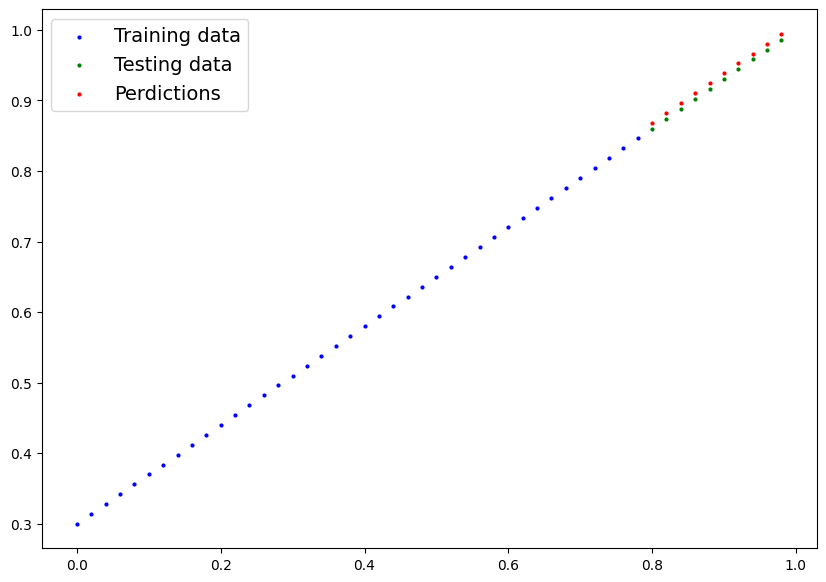

In [21]:
### Let's make some new perdictions now on the model we have: 
with torch.inference_mode():
    y_preds_new = model_0(X_test)

## Plotting the previus pred and new pred:
plot_perdictions(perdictions=y_preds_better)

plot_perdictions(perdictions=y_preds_new)

**My Explanation of the Model** 
- We first set the model to train since we are in a training loop. ``.
- Then we input the data, and we send it to the model to calculate the prediction. ``. Also known as a forward pass. 
- Then we compute the loss of that prediction, using the training data (y_train_target) and the y_pred. ``
-PyTorch builds a computation graph while computing the prediction and the loss. The loss tensor is the final node of that graph. The question now becomes, hmmmm, should I increase the weight & bias or decrease them? (changing the parameters that have requires_grad=True)
- So we have to calculate the gradients.
- First, we set the gradients to zero because PyTorch accumulates gradients by default. ``
- Then the optimizer uses the computation graph and value of gradient to we have `` since the optimizer is responsible for calculating the gradients.
- Now, to calculate the gradients, we run the backpropagation algorithm starting from the loss. ``
- Ok, now we have the gradients and the old weights, and we have to update the weights. So we adjust the parameters using the information we have about the gradient. ``

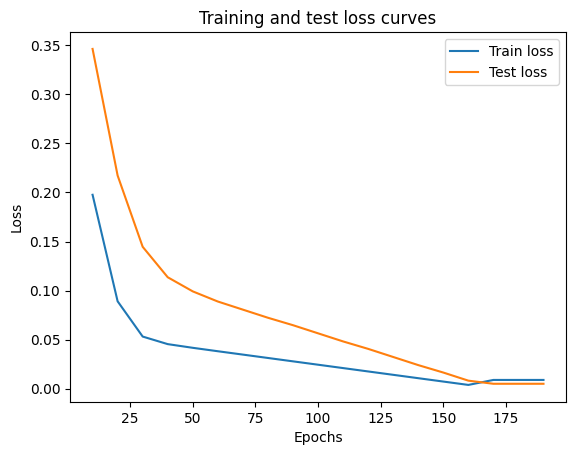

In [22]:
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend();

## 🔵 Saving a Model

We save the model to reuse it, send it to other people and do a lot more with it. 
So how do we do it?

Three main methods to save and load the model: 
1. `torch.save()` - allows you to save a PyTorch object in Python pickle format.
2. `torch.load()` - allows you to load a saved PyTorch object
3.  `torch.nn.Module.load_state_dict()` - this allows you to load a model's saved state dictionary.

**State_dict** is a python dictionary object that maps each layer (model's parameters) to its paramter tensor (so like the value of it and more info)


In [23]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [24]:
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.01,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

In [28]:
### 🟢 Saving our PyTorch Model
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create the model's save path
MODEL_NAME = "01_pytorch_workflow_model_0.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(MODEL_SAVE_PATH)

# 3. Save the model state dict (since it is a recommended way of saving your model
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)


models/01_pytorch_workflow_model_0.pt
Saving model to models/01_pytorch_workflow_model_0.pt


### Note

To save your model, there are 2 different ways of doing it: 
1. To save the model's state dict, which is the recommended way to do so.
2. To save the entire model

Dig into which one's better and the reasons behind it. 

In [29]:
!ls -l models

total 8
-rw-r--r--  1 adrina  staff  2117 Jul  5 20:59 01_pytorch_workflow_model_0.pt


### 🟢 Loading a PyTorch Model

since we saved our model's `state_dict()` rather than the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [31]:
model_0.state_dict() # This is what we saved

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [34]:
# To load in a saved_state_dict, we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()
loaded_model_0.state_dict() # this has random parameters


OrderedDict([('weights', tensor([-1.1229])), ('bias', tensor([-0.1863]))])

In [36]:
# Load the saved state_dict of model_0
# This will update the new instance with the updated parameters
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [41]:
# Let's check this loaded model
# Making Perdictions:

loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [42]:
model_0.eval()
with torch.inference_mode():
    y_preds_original = model_0(X_test)


loaded_model_preds == y_preds_original

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])